In [1]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
import pandas as pd
from sklearn import preprocessing
import matplotlib.pyplot as plt

In [3]:
header = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 
                  'capital-loss', 'hours-per-week', 'native-country', 'salary']
try:
  df_temp = pd.read_csv("../data/adults.csv",index_col=False, skipinitialspace=True,header=None,names=header)
except:
    print("File not found")

In [8]:
df = df_temp
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  salary          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [9]:
df = df.replace('?', np.nan)
df[pd.isnull(df).any(axis=1)].shape

(3620, 15)

In [10]:
df.dropna(inplace=True)

In [11]:
df.shape

(45222, 15)

In [18]:
df.drop('education-num', axis=1, inplace=True)

In [23]:
categorical_columns = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
label_column = ['salary']

In [24]:
def show_unique_values(columns):
  for column in columns:
    uniq = df[column].unique().tolist()
    print(column+ " has "+ str(len(uniq)) +" values" + " : " + str(uniq))
show_unique_values(categorical_columns)
show_unique_values(label_column)

workclass has 7 values : ['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov', 'Local-gov', 'Self-emp-inc', 'Without-pay']
education has 16 values : ['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college', 'Assoc-acdm', '7th-8th', 'Doctorate', 'Assoc-voc', 'Prof-school', '5th-6th', '10th', 'Preschool', '12th', '1st-4th']
marital-status has 7 values : ['Never-married', 'Married-civ-spouse', 'Divorced', 'Married-spouse-absent', 'Separated', 'Married-AF-spouse', 'Widowed']
occupation has 14 values : ['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners', 'Prof-specialty', 'Other-service', 'Sales', 'Transport-moving', 'Farming-fishing', 'Machine-op-inspct', 'Tech-support', 'Craft-repair', 'Protective-serv', 'Armed-Forces', 'Priv-house-serv']
relationship has 6 values : ['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried', 'Other-relative']
race has 5 values : ['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other']
sex has 2 values : ['Male', 'Femal

In [25]:
def convert_to_int(columns):
  for column in columns:
    unique_values = df[column].unique().tolist()
    dic = {}
    for indx, val in enumerate(unique_values):
      dic[val]=indx
    df[column] = df[column].map(dic).astype(int)
    print(column + " done!")
convert_to_int(label_column)
show_unique_values(label_column)

salary done!
salary has 2 values : [0, 1]


In [26]:
def convert_to_onehot(data,columns):
  dummies = pd.get_dummies(data[columns])
  data = data.drop(columns, axis=1)
  data = pd.concat([data, dummies], axis=1)
  return data

In [27]:
df = convert_to_onehot(df,categorical_columns)

In [28]:
normalize_columns = ['age', 'fnlwgt', 'capital-gain','capital-loss','hours-per-week']

In [29]:
def show_values(columns):
  for column in columns:
    max_val = df[column].max()
    min_val = df[column].min()
    mean_val = df[column].mean()
    var_val = df[column].var()
    print(column +': values=['+str(min_val)+','+str(max_val)+'] , mean='+str(mean_val)+' , var='+str(var_val))
show_values(normalize_columns)

age: values=[17,90] , mean=38.547941267524656 , var=174.71209312779473
fnlwgt: values=[13492,1490400] , mean=189734.7343107337 , var=11159639548.606062
capital-gain: values=[0,99999] , mean=1101.4303436380524 , var=56346492.60215572
capital-loss: values=[0,4356] , mean=88.595418159303 , var=163989.43649566895
hours-per-week: values=[1,99] , mean=40.93801689443191 , var=144.18025389432105


In [30]:
df_1 = df.copy()

In [31]:
def normalize(columns):
  scaler = preprocessing.StandardScaler()
  df[columns] = scaler.fit_transform(df[columns])
normalize(normalize_columns)
show_values(normalize_columns)

age: values=[-1.6302308284607552,3.8926564395212115] , mean=-2.3254240169053742e-17 , var=1.0000221136197784
fnlwgt: values=[-1.668364500112278,12.312472138449555] , mean=5.192923226940717e-17 , var=1.000022113619778
capital-gain: values=[-0.14673320201326512,13.175192739902075] , mean=-1.971896717038003e-17 , var=1.0000221136197782
capital-loss: values=[-0.21878025661034578,10.538060419744602] , mean=2.498259585729422e-17 , var=1.0000221136197784
hours-per-week: values=[-3.326123764725461,4.835526569709145] , mean=2.144732285862051e-16 , var=1.0000221136197784


In [32]:
df.head()

,age,fnlwgt,capital-gain,capital-loss,hours-per-week,salary,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.034201,-1.062295,0.142888,-0.21878,-0.078120,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.866417,-1.007438,-0.146733,-0.21878,-2.326738,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.041455,0.245284,-0.146733,-0.21878,-0.078120,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,1.093385,0.425853,-0.146733,-0.21878,-0.078120,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,-0.798015,1.407393,-0.146733,-0.21878,-0.078120,0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [34]:
from sklearn.model_selection import train_test_split
x_data = df.drop('salary', axis=1)
y_labels = df['salary']
x_train, x_test, y_train, y_test = train_test_split(x_data, y_labels, test_size=0.2, shuffle=True)
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(36177, 103) (36177,)
(9045, 103) (9045,)


In [ ]:
keras.backend.clear_session()
np.random.seed(1947)
tf.random.set_seed(1947)

In [76]:
# Rebuild model to clear any cached state issues
keras.backend.clear_session()

# Configure GPU for faster training
print("GPU Configuration:")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable memory growth to avoid allocating all GPU memory at once
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs available: {len(gpus)}")
        print(f"GPU names: {[gpu.name for gpu in gpus]}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found. Training will use CPU (slower).")

# FIXED f1 metric - ensures output is between 0-1
def f1_fixed(y_true, y_pred):
    def recall_m(y_true, y_pred):
        true_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
        possible_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_true, 0, 1)))
        recall = true_positives / (possible_positives + tf.keras.backend.epsilon())
        return recall

    def precision_m(y_true, y_pred):
        true_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
        predicted_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + tf.keras.backend.epsilon())
        return precision

    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    # Ensure F1 is between 0-1 by using tf.clip
    f1_val = 2*((precision*recall)/(precision+recall+tf.keras.backend.epsilon()))
    return tf.clip_by_value(f1_val, 0.0, 0.8)

# ADJUSTED: Reduce class weights for better precision (less aggressive balancing)
from sklearn.utils.class_weight import compute_class_weight
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train.values)
# Scale down the minority class weight to reduce false positives
class_weights = {0: 1.0, 1: class_weights_array[1] * 0.7}  # Reduce weight by 30%
print(f"Adjusted class weights for precision: {class_weights}")

# Force operations to run on GPU if available
with tf.device('/GPU:0' if gpus else '/CPU:0'):
    model = keras.models.Sequential([
        keras.layers.InputLayer(x_train.shape[1:], name='input_layer'),
        keras.layers.Dense(100, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01)), 
        keras.layers.Dropout(0.2),  # Increased dropout
        keras.layers.Dense(50, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dropout(0.2),  # Increased dropout
        keras.layers.Dense(1, activation="sigmoid", name='output_layer'),
    ])
    model.compile(loss=keras.losses.BinaryCrossentropy(), 
                  optimizer=keras.optimizers.Adam(learning_rate=0.0007),  # Slightly lower LR for careful training
                  metrics=["accuracy", "Precision", "Recall", f1_fixed])

# Convert to numpy arrays
X = x_train.values.astype('float32')
y = y_train.values.ravel().astype('float32')

# Add callbacks
early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-6)

# Train with adjusted class weights for better precision
history = model.fit(X, y, 
                    epochs=100,
                    batch_size=256,
                    verbose=2,
                    class_weight=class_weights,  # Adjusted weights for precision
                    callbacks=[early_stop, reduce_lr])

print("\n" + "="*50)
print("Training Complete - Precision-Optimized Model")
print(f"Final metrics: Loss={history.history['loss'][-1]:.4f}, "
      f"Accuracy={history.history['accuracy'][-1]:.4f}, "
      f"Precision={history.history['Precision'][-1]:.4f}, "
      f"Recall={history.history['Recall'][-1]:.4f}, "
      f"F1={history.history['f1_fixed'][-1]:.4f}")
print("="*50)



GPU Configuration:
No GPU found. Training will use CPU (slower).
Adjusted class weights for precision: {0: 1.0, 1: 1.4131640625}
Epoch 1/100
142/142 - 1s - 9ms/step - Precision: 0.6028 - Recall: 0.4884 - accuracy: 0.7936 - f1_fixed: 0.8000 - loss: 1.4227 - learning_rate: 7.0000e-04
Epoch 2/100
142/142 - 0s - 2ms/step - Precision: 0.6669 - Recall: 0.6586 - accuracy: 0.8340 - f1_fixed: 0.8000 - loss: 0.6575 - learning_rate: 7.0000e-04
Epoch 3/100
142/142 - 0s - 2ms/step - Precision: 0.6861 - Recall: 0.6742 - accuracy: 0.8429 - f1_fixed: 0.8000 - loss: 0.4986 - learning_rate: 7.0000e-04
Epoch 4/100
142/142 - 0s - 2ms/step - Precision: 0.6827 - Recall: 0.6760 - accuracy: 0.8419 - f1_fixed: 0.8000 - loss: 0.4622 - learning_rate: 7.0000e-04
Epoch 5/100
142/142 - 0s - 2ms/step - Precision: 0.6853 - Recall: 0.6812 - accuracy: 0.8436 - f1_fixed: 0.8000 - loss: 0.4483 - learning_rate: 7.0000e-04
Epoch 6/100
142/142 - 0s - 2ms/step - Precision: 0.6893 - Recall: 0.6808 - accuracy: 0.8450 - f1_fixe

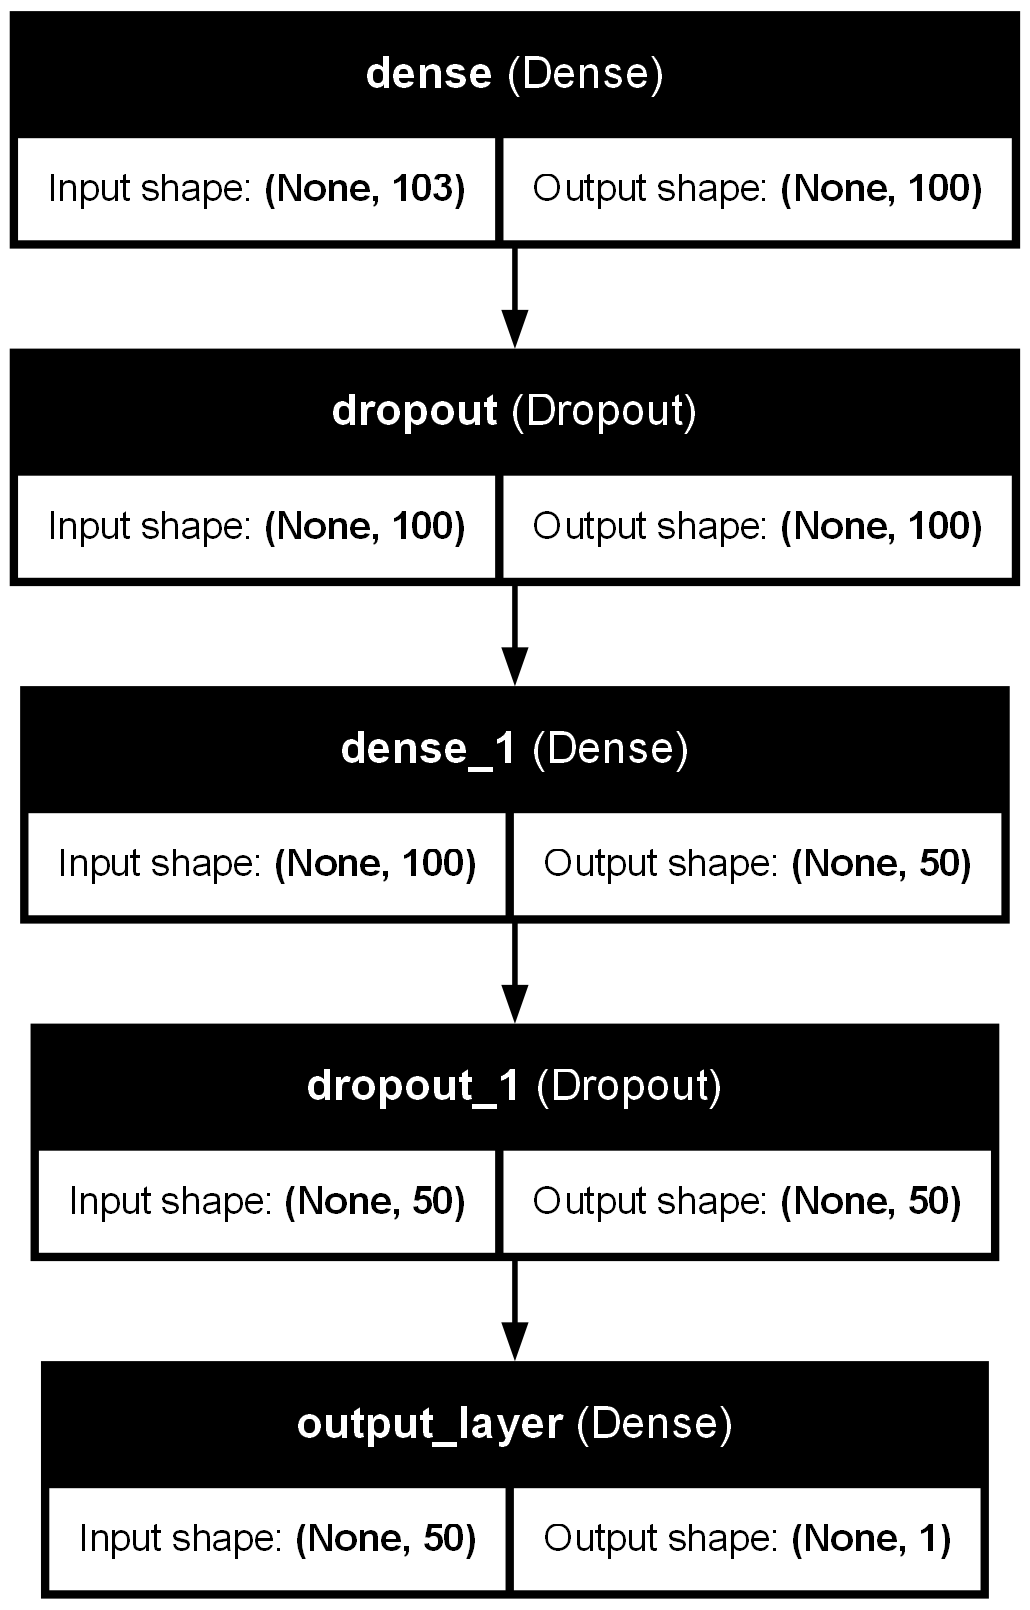

In [77]:
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, expand_nested=True)